In [1]:
from pathlib import Path

path = Path("artifacts") / "data.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install once in the project venv, then restart the kernel if needed:
# pip install -r requirements-dev.txt

ERROR: Ignored the following yanked versions: 0.0.post2
ERROR: Could not find a version that satisfies the requirement sklearn==1.6.1 (from versions: 0.0, 0.0.post1, 0.0.post4, 0.0.post5, 0.0.post7, 0.0.post9, 0.0.post10, 0.0.post11, 0.0.post12)
ERROR: No matching distribution found for sklearn==1.6.1


In [3]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv(path).set_index('ID')

In [5]:
data.head()

,Application creation month,NUMBER CREDITS IN KBI 3,NUMBER CREDITS IN KBI 6,ADMINISTRATIVE VIOLATION,CRIMINAL VIOLATION,NUMBER CREDITS IN KBI,NUMBER REQUESTS IN KBI,NUMBER REQUESTS IN KBI ALL,CLOSED CREDITS IN KBI,CLOSED CREDITS IN KBI YEAR,...,REAL ESTATE,VEHICLE,PERSONNEL PHONE,ACCOUNTING PHONE,Age,Length work,Matching address of registration and residence,Loans total,Credit load,Marker
ID,,,,,,,,,,,,,,,,,,,,,
1,autumn,0,0,0,0,1,1,3,2,1,...,yes,yes,no,no,34,8.0,no,3,0.21,good
2,summer,1,2,1,2,1,1,4,3,1,...,no,no,no,no,46,5.0,yes,4,0.16,good
3,autumn,0,0,0,0,0,0,1,2,2,...,yes,yes,no,no,47,0.5,yes,2,0.05,good
4,autumn,1,1,0,0,3,0,2,0,0,...,yes,yes,no,no,36,10.0,yes,3,0.54,good
5,spring,1,2,2,0,3,0,10,10,4,...,yes,yes,no,no,44,11.0,yes,13,0.34,good


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2565 entries, 1 to 2,565
Data columns (total 55 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Application creation month                      2565 non-null   object 
 1   NUMBER CREDITS IN KBI 3                         2565 non-null   int64  
 2   NUMBER CREDITS IN KBI 6                         2565 non-null   int64  
 3   ADMINISTRATIVE VIOLATION                        2565 non-null   int64  
 4   CRIMINAL VIOLATION                              2565 non-null   int64  
 5   NUMBER CREDITS IN KBI                           2565 non-null   int64  
 6   NUMBER REQUESTS IN KBI                          2565 non-null   int64  
 7   NUMBER REQUESTS IN KBI ALL                      2565 non-null   int64  
 8   CLOSED CREDITS IN KBI                           2565 non-null   int64  
 9   CLOSED CREDITS IN KBI YEAR                   

In [7]:
data.describe()

,NUMBER CREDITS IN KBI 3,NUMBER CREDITS IN KBI 6,ADMINISTRATIVE VIOLATION,CRIMINAL VIOLATION,NUMBER CREDITS IN KBI,NUMBER REQUESTS IN KBI,NUMBER REQUESTS IN KBI ALL,CLOSED CREDITS IN KBI,CLOSED CREDITS IN KBI YEAR,OVERDUES IN KBI,...,LATECOUNTPAY 8 30,LATECOUNTPAY 31 90,LATECOUNTPAY 91 180,LATECOUNTPAY 181,CHILDREN,MINORS,Age,Length work,Loans total,Credit load
count,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,...,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000
mean,0.215984,0.593372,0.947368,0.147368,1.517739,0.642885,5.689669,3.194542,0.698246,0.816374,...,0.497856,0.106433,0.016374,0.017934,1.224172,0.763743,38.118129,6.737661,4.712281,0.194932
std,0.555902,1.067695,1.958212,0.602353,1.431543,0.852381,5.342810,3.190880,1.126625,2.479755,...,2.083779,0.595728,0.152094,0.161862,0.929685,0.867337,9.880195,6.815279,3.993836,0.155481
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.300000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,30.000000,2.000000,2.000000,0.060000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,37.000000,4.300000,4.000000,0.160000
75%,0.000000,1.000000,1.000000,0.000000,2.000000,1.000000,8.000000,5.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,45.000000,9.500000,7.000000,0.280000
max,7.000000,17.000000,26.000000,6.000000,12.000000,9.000000,61.000000,37.000000,16.000000,28.000000,...,40.000000,12.000000,3.000000,4.000000,7.000000,5.000000,64.000000,43.000000,41.000000,0.970000


**EDA**

Предварительная обработка данных, выделение категориальных и интервальных переменных, обработка пропусков

In [8]:
data.columns

Index(['Application creation month', 'NUMBER CREDITS IN KBI 3',
       'NUMBER CREDITS IN KBI 6', 'ADMINISTRATIVE VIOLATION',
       'CRIMINAL VIOLATION', 'NUMBER CREDITS IN KBI', 'NUMBER REQUESTS IN KBI',
       'NUMBER REQUESTS IN KBI ALL', 'CLOSED CREDITS IN KBI',
       'CLOSED CREDITS IN KBI YEAR', 'OVERDUES IN KBI',
       'DURATION LAST OVERDUE', 'COUNTGUARANTEE', 'COUNTCLOSEGUARANTEE',
       'COUNTOPENGUARANTEE', 'DURATIONGREATESTDELAYLASTYEAR',
       'DURATIONGREATESTDELAYLASTALL', 'LATECOUNTSUMM 1 7',
       'LATECOUNTSUMM 8 30', 'LATECOUNTSUMM 31 90', 'LATECOUNTSUMM 91 180',
       'LATECOUNTSUMM 181', 'LATECOUNTPRC 1 7', 'LATECOUNTPRC 8 30',
       'LATECOUNTPRC 31 90', 'LATECOUNTPRC 91 180', 'LATECOUNTPRC 181',
       'LATECOUNTPAY 1 7', 'LATECOUNTPAY 8 30', 'LATECOUNTPAY 31 90',
       'LATECOUNTPAY 91 180', 'LATECOUNTPAY 181', 'SEX', 'BIRTH CNTR',
       'MARITAL STATUS', 'CHILDREN', 'MINORS', 'HOMEPHONE', 'WORKPHONE',
       'MOBILE 1', 'REG TOWNTYPE', 'HOME TOWNTYPE'

In [9]:
data['Marker'] = data['Marker'].replace({'good': 1, 'bad': 0})
data.head()

,Application creation month,NUMBER CREDITS IN KBI 3,NUMBER CREDITS IN KBI 6,ADMINISTRATIVE VIOLATION,CRIMINAL VIOLATION,NUMBER CREDITS IN KBI,NUMBER REQUESTS IN KBI,NUMBER REQUESTS IN KBI ALL,CLOSED CREDITS IN KBI,CLOSED CREDITS IN KBI YEAR,...,REAL ESTATE,VEHICLE,PERSONNEL PHONE,ACCOUNTING PHONE,Age,Length work,Matching address of registration and residence,Loans total,Credit load,Marker
ID,,,,,,,,,,,,,,,,,,,,,
1,autumn,0,0,0,0,1,1,3,2,1,...,yes,yes,no,no,34,8.0,no,3,0.21,1
2,summer,1,2,1,2,1,1,4,3,1,...,no,no,no,no,46,5.0,yes,4,0.16,1
3,autumn,0,0,0,0,0,0,1,2,2,...,yes,yes,no,no,47,0.5,yes,2,0.05,1
4,autumn,1,1,0,0,3,0,2,0,0,...,yes,yes,no,no,36,10.0,yes,3,0.54,1
5,spring,1,2,2,0,3,0,10,10,4,...,yes,yes,no,no,44,11.0,yes,13,0.34,1


In [10]:
# только в первой строчке были наны
data = data.dropna()

In [11]:
from src.features import CATEGORICAL, FEATURES, NUMERICAL

features = FEATURES
features

In [12]:
# тот же контракт, что у train.py / app.py
categorical = CATEGORICAL
categorical

['Application creation month',
 'DURATION LAST OVERDUE',
 'DURATIONGREATESTDELAYLASTALL',
 'SEX',
 'BIRTH CNTR',
 'MARITAL STATUS',
 'HOMEPHONE',
 'WORKPHONE',
 'MOBILE 1',
 'REG TOWNTYPE',
 'HOME TOWNTYPE',
 'EMPLOYMENT',
 'EDUCATION',
 'PROFESSION',
 'REAL ESTATE',
 'VEHICLE',
 'PERSONNEL PHONE',
 'ACCOUNTING PHONE',
 'Matching address of registration and residence']

In [13]:
numerical = NUMERICAL
numerical

['LATECOUNTSUMM 8 30',
 'Length work',
 'NUMBER CREDITS IN KBI 6',
 'OVERDUES IN KBI',
 'LATECOUNTSUMM 31 90',
 'COUNTCLOSEGUARANTEE',
 'Age',
 'MINORS',
 'COUNTGUARANTEE',
 'DURATIONGREATESTDELAYLASTYEAR',
 'LATECOUNTPRC 181',
 'LATECOUNTPRC 1 7',
 'LATECOUNTPAY 1 7',
 'LATECOUNTPAY 8 30',
 'CRIMINAL VIOLATION',
 'Credit load',
 'LATECOUNTSUMM 91 180',
 'LATECOUNTPAY 31 90',
 'NUMBER CREDITS IN KBI 3',
 'LATECOUNTPRC 31 90',
 'LATECOUNTPAY 91 180',
 'LATECOUNTPRC 8 30',
 'CHILDREN',
 'CLOSED CREDITS IN KBI YEAR',
 'LATECOUNTSUMM 1 7',
 'NUMBER REQUESTS IN KBI ALL',
 'LATECOUNTPAY 181',
 'LATECOUNTSUMM 181',
 'LATECOUNTPRC 91 180',
 'ADMINISTRATIVE VIOLATION',
 'CLOSED CREDITS IN KBI',
 'NUMBER CREDITS IN KBI',
 'Loans total',
 'COUNTOPENGUARANTEE',
 'NUMBER REQUESTS IN KBI']

Пробуем обучать модель, поисследовав разные подходы была выбрана модель бустинга из библиотеки xgboost

In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split

import xgboost as xgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

SEED = 42

In [15]:
y = data['Marker']
X = data.drop(columns = 'Marker', inplace=False)
X = X[features]

In [16]:
from sklearn.preprocessing import LabelEncoder
# кодируем категориальные признаки

label_encoders = {}
for col in categorical:
        le = LabelEncoder()
        le.fit(X[col].astype('str'))
        X[col] = le.transform(X[col].astype('str'))
        label_encoders[col] = le
X[categorical].head()

,Application creation month,DURATION LAST OVERDUE,DURATIONGREATESTDELAYLASTALL,SEX,BIRTH CNTR,MARITAL STATUS,HOMEPHONE,WORKPHONE,MOBILE 1,REG TOWNTYPE,HOME TOWNTYPE,EMPLOYMENT,EDUCATION,PROFESSION,REAL ESTATE,VEHICLE,PERSONNEL PHONE,ACCOUNTING PHONE,Matching address of registration and residence
ID,,,,,,,,,,,,,,,,,,,
2,2,1,137,1,2,0,1,1,0,1,1,4,3,7,0,0,0,0,1
3,0,0,0,0,2,0,1,1,0,1,1,4,1,13,1,1,0,0,1
4,0,0,0,0,13,0,1,1,0,1,1,4,1,5,1,1,0,0,1
5,1,13,20,1,2,0,1,1,0,1,1,4,4,0,1,1,0,0,1
6,0,0,0,1,2,2,1,1,0,4,4,4,1,15,0,0,0,0,1


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED)

In [18]:
len(X_train) + len(X_valid) + len(X_test) == len(X)

True

In [19]:
params = {
    "n_estimators": 500,
    "eta": 0.3,
    "gamma": 0,
    "max_depth": 6,
    "lambda": 1,
    "alpha": 0,
    "booster": "gbtree",
    "verbosity": 2,

}

model = xgb.XGBClassifier(**params)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])

[23:54:37] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (1634, 54, 88236).
[23:54:37] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (545, 54, 29430).
[0]	validation_0-logloss:0.25653
[1]	validation_0-logloss:0.24685
[2]	validation_0-logloss:0.24528
[3]	validation_0-logloss:0.24220
[4]	validation_0-logloss:0.24155
[5]	validation_0-logloss:0.24524
[6]	validation_0-logloss:0.24722
[7]	validation_0-logloss:0.25065
[8]	validation_0-logloss:0.25266
[9]	validation_0-logloss:0.25482
[10]	validation_0-logloss:0.25511
[11]	validation_0-logloss:0.25848
[12]	validation_0-logloss:0.26031
[13]	validation_0-logloss:0.26002
[14]	validation_0-logloss:0.26261
[15]	validation_0-logloss:0.26354
[16]	validation_0-logloss:0.26876
[17]	validation_0-logloss:0.27168
[18]	validation_0-logloss:0.27132
[19]	validation_0-logloss:0.27431
[20]	validation_0-logloss:0.27435
[21]	validation_0-logloss:0.27736
[22]	vali

XGBClassifier(alpha=0, base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.3, eval_metric=None,
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=1, learning_rate=None,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, ...)

In [20]:
model_es = xgb.XGBClassifier(**params, early_stopping_rounds = 20)
model_es.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])

[23:54:41] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (1634, 54, 88236).
[23:54:41] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (545, 54, 29430).
[0]	validation_0-logloss:0.25653
[1]	validation_0-logloss:0.24685
[2]	validation_0-logloss:0.24528
[3]	validation_0-logloss:0.24220
[4]	validation_0-logloss:0.24155
[5]	validation_0-logloss:0.24524
[6]	validation_0-logloss:0.24722
[7]	validation_0-logloss:0.25065
[8]	validation_0-logloss:0.25266
[9]	validation_0-logloss:0.25482
[10]	validation_0-logloss:0.25511
[11]	validation_0-logloss:0.25848
[12]	validation_0-logloss:0.26031
[13]	validation_0-logloss:0.26002
[14]	validation_0-logloss:0.26261
[15]	validation_0-logloss:0.26354
[16]	validation_0-logloss:0.26876
[17]	validation_0-logloss:0.27168
[18]	validation_0-logloss:0.27132
[19]	validation_0-logloss:0.27431
[20]	validation_0-logloss:0.27435
[21]	validation_0-logloss:0.27736
[22]	vali

XGBClassifier(alpha=0, base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=20,
              enable_categorical=False, eta=0.3, eval_metric=None,
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=1, learning_rate=None,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, ...)

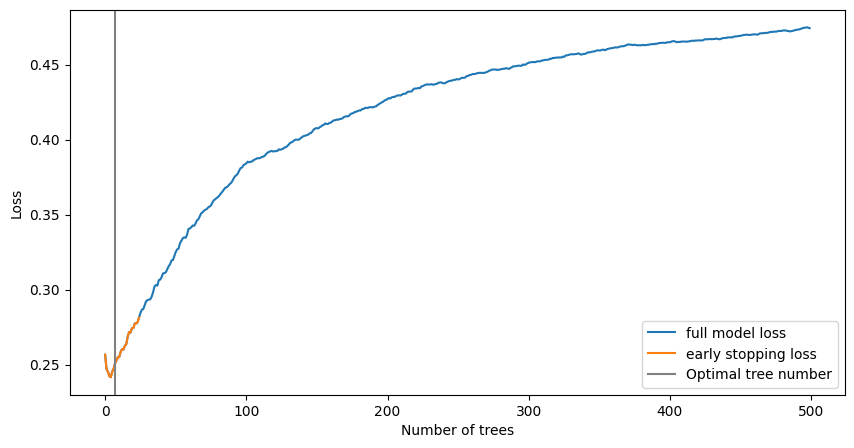

In [21]:
results_full = model.evals_result()
results_es = model_es.evals_result()

plt.figure(figsize=(10,5))
plt.plot(results_full["validation_0"]["logloss"], label="full model loss")
plt.plot(results_es["validation_0"]["logloss"], label="early stopping loss")
plt.axvline(7, color="gray", label="Optimal tree number")
plt.xlabel("Number of trees")
plt.ylabel("Loss")
plt.legend();

На графике показано, что RMSE снижается только в течение первых 7 итераций. Затем она начинает расти. Ранняя остановка сокращает время обучения, поскольку модель останавливается, если её характеристики не улучшаются. Кроме того, сохраняется модель с наименьшей ошибкой, а не последняя.

In [22]:
pred = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, pred)

np.float64(0.7978409443926685)

In [23]:
pred = model_es.predict_proba(X_test)[:,1]
roc_auc_score(y_test, pred)

np.float64(0.7942684063373718)

In [24]:
param_grid = {
    "n_estimators": [5, 10, 15, 20, 50],
    "eta": [1e-1, 1e-2, 3e-1],
    "gamma": [0.1, 1],
    "max_depth": [4, 6, 8],
    "lambda": [0.1, 1],
    "alpha": [0,0.1,1],
    "verbosity": [0]
}

xgb_model = xgb.XGBClassifier()

grid_search = GridSearchCV(
    estimator=xgb_model, param_grid=param_grid, cv=5, n_jobs=-1)


grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'alpha': [0, 0.1, 1], 'eta': [0.1, 0.01, 0.3],
                         'gamma': [0.1, 1], 'lambda': [0.1, 1],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [5, 10, 15, 20, 50],
                         'verbosity': [0]})

In [25]:
parameters = grid_search.best_params_
parameters["early_stopping_rounds"] = 10
parameters

{'alpha': 0.1,
 'eta': 0.1,
 'gamma': 1,
 'lambda': 1,
 'max_depth': 4,
 'n_estimators': 50,
 'verbosity': 0,
 'early_stopping_rounds': 10}

In [26]:
model_best = xgb.XGBClassifier(**parameters)
model_best.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])
results = model_best.evals_result()

[0]	validation_0-logloss:0.26014
[1]	validation_0-logloss:0.25618
[2]	validation_0-logloss:0.25213
[3]	validation_0-logloss:0.25036
[4]	validation_0-logloss:0.24787
[5]	validation_0-logloss:0.24637
[6]	validation_0-logloss:0.24438
[7]	validation_0-logloss:0.24167
[8]	validation_0-logloss:0.24094
[9]	validation_0-logloss:0.23882
[10]	validation_0-logloss:0.23745
[11]	validation_0-logloss:0.23780
[12]	validation_0-logloss:0.23766
[13]	validation_0-logloss:0.23727
[14]	validation_0-logloss:0.23579
[15]	validation_0-logloss:0.23567
[16]	validation_0-logloss:0.23584
[17]	validation_0-logloss:0.23582
[18]	validation_0-logloss:0.23485
[19]	validation_0-logloss:0.23457
[20]	validation_0-logloss:0.23466
[21]	validation_0-logloss:0.23391
[22]	validation_0-logloss:0.23303
[23]	validation_0-logloss:0.23343
[24]	validation_0-logloss:0.23349
[25]	validation_0-logloss:0.23402
[26]	validation_0-logloss:0.23371
[27]	validation_0-logloss:0.23345
[28]	validation_0-logloss:0.23365
[29]	validation_0-loglos

In [27]:
pred = model_best.predict_proba(X_test)[:,1]
roc_auc_score(y_test, pred)

np.float64(0.8193150046598322)

In [33]:
import joblib
from pathlib import Path

artifacts = Path("artifacts")
joblib.dump(model_best, artifacts / "notebook_xgboost.joblib", compress=True)
joblib.dump(label_encoders, artifacts / "notebook_label_encoders.joblib", compress=True)

['/label_encoders.joblib']

In [34]:
modelReload = joblib.load(Path("artifacts") / "notebook_xgboost.joblib")
pred_new = modelReload.predict_proba(X_test)[:, 1]

In [35]:
roc_auc_score(y_test, pred_new)

np.float64(0.8193150046598322)

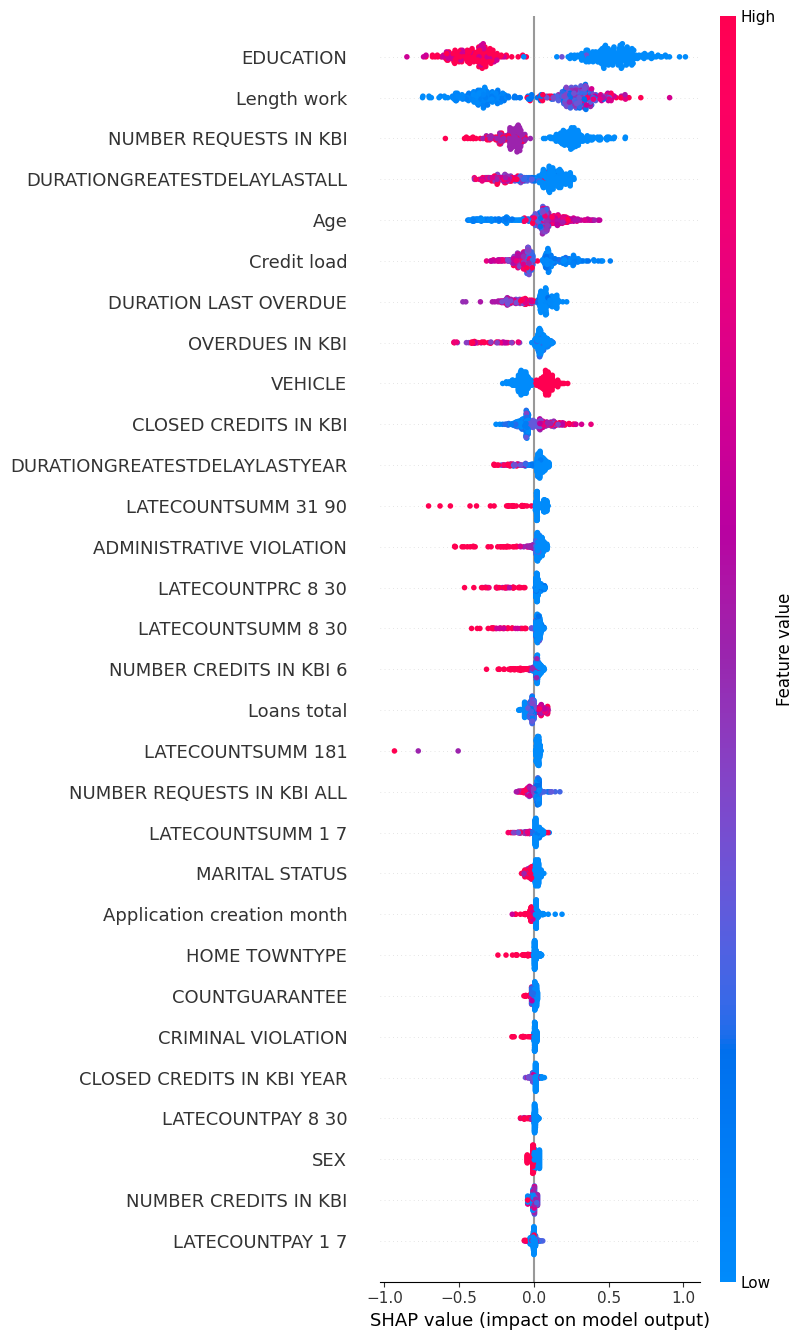

In [36]:
# из интересного здесь можно посмотреть feature_importance
import shap

shap_test = shap.TreeExplainer(model_best).shap_values(X_test)
shap.summary_plot(shap_test, X_test, max_display=30)

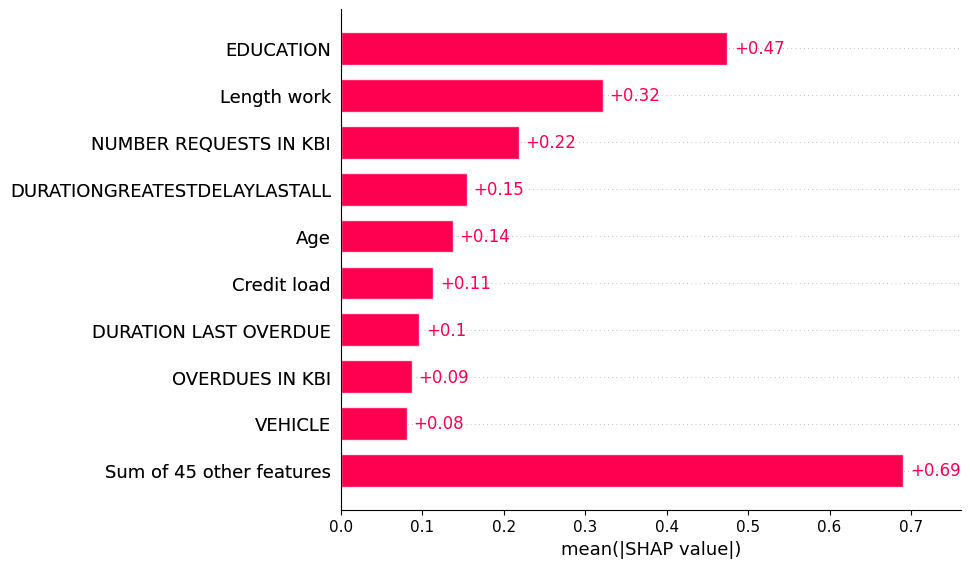

In [37]:
explanation= shap.Explanation(values=shap_test,
                             data=X_test,
                             feature_names=X_test.columns)
shap.plots.bar(explanation, max_display=10)

Мы имеем задачу с бинарной классификацией.
Получился roc_auc_score 0.82, что является достаточно хорошим показателем, для такой метрики идеальная классификатор имеет скор 1.0.

Оценка AUC-ROC (площадь под кривой рабочей характеристики приемника) представляет собой единую метрику, которая суммирует общую производительность бинарной классификации, что указывает на его способность различать положительные и отрицательные классы.

Так же можно потестировать модель логистической регрессии, но они как правило показывают хуже результат, еще из бустингов можно попробовать lightgbm или randomforest, сделать более тщательный тьюнинг гиперпараметров можно с помощью фреймворка optuna.